<a href="https://colab.research.google.com/github/ebitnet65/geometry-of-thermodynamics-review/blob/master/PCCP_CPE_Figure6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

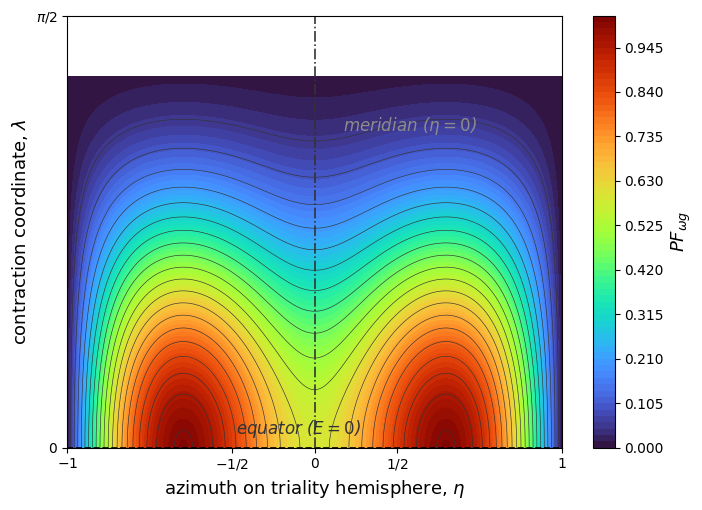

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters from Mathematica notebook
Gamma1 = 1.0
Gamma2 = 0.55
z0 = -0.85
phi = np.pi / 2

# Triality/Mercator chart
n_eta = 500
n_lam = 400

eta = np.linspace(-np.pi/2, np.pi/2, n_eta)
lam = np.linspace(0, 1.35, n_lam)   # Mathematica used 0 to 1.35

ETA, LAM = np.meshgrid(eta, lam)

C = np.cos(LAM) * np.cos(ETA)
P = np.cos(LAM) * np.sin(ETA)
E = np.sin(LAM)

PF = (
    -np.sin(phi) / (2 * Gamma1 * Gamma2 * z0)
    * C
    * (Gamma2 * (C**2 + 2 * P**2)
       - Gamma1 * P**2 * np.cos(2 * phi))
)

fig, ax = plt.subplots(figsize=(7.2, 5.2))

levels = 20
cf = ax.contourf(ETA, LAM, PF, levels=80, cmap="turbo")
cs = ax.contour(ETA, LAM, PF, levels=levels, colors="0.2", linewidths=0.45)

ax.axhline(0, color="k", linestyle="--", linewidth=1.2)
ax.axvline(0, color="0.2", linestyle="-.", linewidth=1.2)

ax.text(-.5, 0.05, r"equator ($E=0$)", fontsize=12, style="italic", color=".2")
ax.text(0.18, 1.15, r"meridian ($\eta=0$)", fontsize=12, style="italic", color="0.55")

ax.set_xlim(-np.pi/2, np.pi/2)
ax.set_ylim(0, 1.35)

ax.set_xlabel(r"azimuth on triality hemisphere, $\eta$", fontsize=13)
ax.set_ylabel(r"contraction coordinate, $\lambda$", fontsize=13)

ax.set_xticks([-np.pi/2, -np.pi/6, 0, np.pi/6, np.pi/2])
ax.set_xticklabels([r"$-1$", r"$-1/2$", r"$0$", r"$1/2$", r"$1$"])

ax.set_yticks([0, np.pi/2])
ax.set_yticklabels([r"$0$", r"$\pi/2$"])

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$PF_{\omega g}$", fontsize=13)

plt.tight_layout()
plt.savefig("CPE_Mercator_PF_omega_g.png", dpi=300, bbox_inches="tight")
plt.show()

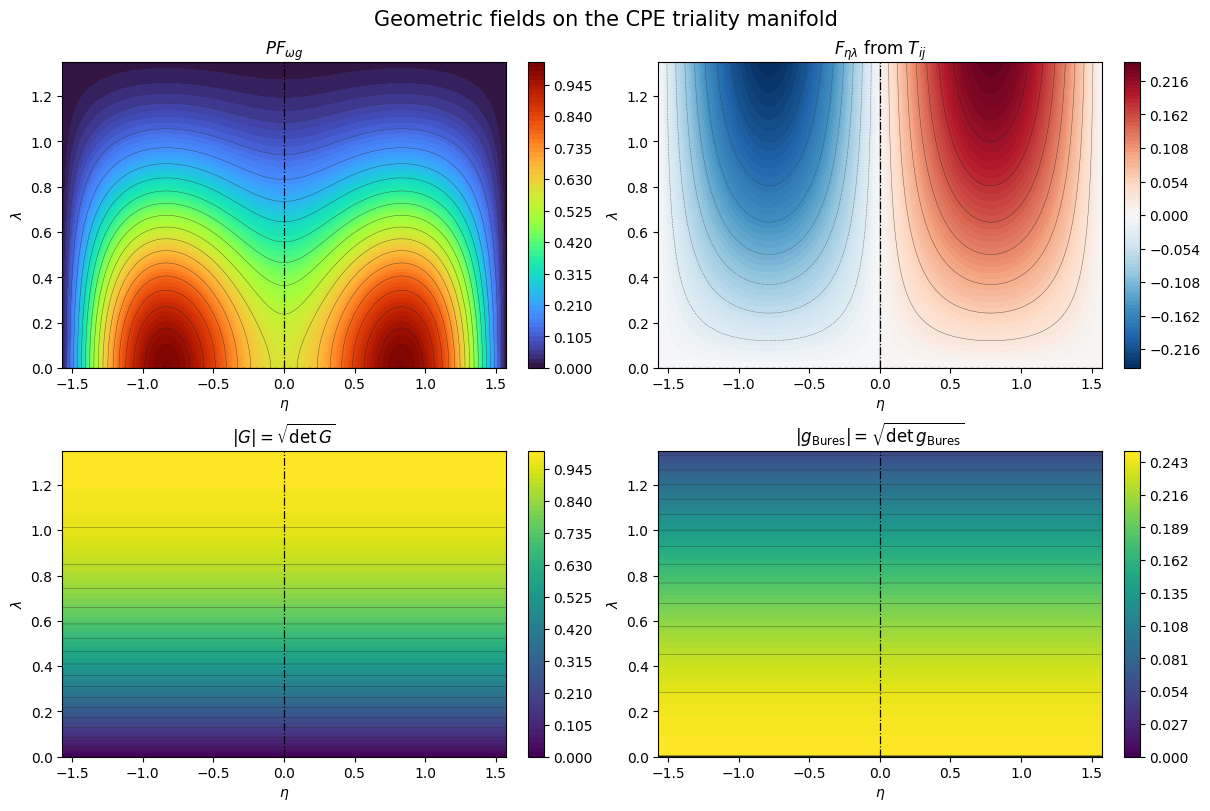

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Triality / Mercator chart
# ============================================================

def triality_grid(n_eta=501, n_lam=401, lam_max=1.35):
    eta = np.linspace(-np.pi/2, np.pi/2, n_eta)
    lam = np.linspace(0.0, lam_max, n_lam)
    ETA, LAM = np.meshgrid(eta, lam)

    C = np.cos(LAM) * np.cos(ETA)
    P = np.cos(LAM) * np.sin(ETA)
    E = np.sin(LAM)

    return eta, lam, ETA, LAM, C, P, E


def bloch_from_cpe(C, P, phi=np.pi/2):
    x = C * np.cos(phi)
    y = C * np.sin(phi)
    z = P
    return np.stack([x, y, z], axis=-1)


# ============================================================
# CPE curvature from complementarity paper
# Regularized field: P F_{omega g}
# ============================================================

def cpe_regularized_curvature(C, P, E, Gamma1=1.0, Gamma2=0.55, z0=-0.85, phi=np.pi/2):
    return (
        -np.sin(phi) / (2.0 * Gamma1 * Gamma2 * z0)
        * C
        * (
            Gamma2 * (C**2 + 2.0 * P**2)
            - Gamma1 * P**2 * np.cos(2.0 * phi)
        )
    )


# ============================================================
# User-supplied Hamiltonian direction htilde(C,P,E,eta,lambda)
# Replace this with the exact JCP2 mapping.
# ============================================================

def htilde_default(ETA, LAM, C, P, E, alpha=None):
    """
    Placeholder Hamiltonian direction.

    IMPORTANT:
    Replace this with the exact normalized Hamiltonian direction
    used in JCP2:
        htilde = h / |h|.

    If alpha is None, use alpha = ETA as a smooth chart example.
    """
    if alpha is None:
        alpha = ETA

    hx = np.cos(alpha)
    hy = np.zeros_like(alpha)
    hz = np.sin(alpha)

    return np.stack([hx, hy, hz], axis=-1)


# ============================================================
# Differential geometry helpers
# ============================================================

def dot(a, b):
    return np.sum(a * b, axis=-1)


def gradients_vector_field(vec, eta, lam):
    """
    vec shape = (n_lam, n_eta, 3)
    returns d_eta vec, d_lam vec.
    """
    d_lam = np.zeros_like(vec)
    d_eta = np.zeros_like(vec)

    for k in range(3):
        d_lam[..., k], d_eta[..., k] = np.gradient(
            vec[..., k],
            lam,
            eta,
            edge_order=2
        )

    return d_eta, d_lam


# ============================================================
# Response tensor from JCP2:
#
# T_ij = dr_i.dr_j + dh_i.dh_j
#        + i( dr_i.dh_j - dr_j.dh_i )
#
# G_ij = Re T_ij
# F_ij = (1/2 beta) Im T_ij
# ============================================================

def response_geometry_on_triality(r, htilde, eta, lam, beta=1.0):
    dr_eta, dr_lam = gradients_vector_field(r, eta, lam)
    dh_eta, dh_lam = gradients_vector_field(htilde, eta, lam)

    G_eta_eta = dot(dr_eta, dr_eta) + dot(dh_eta, dh_eta)
    G_lam_lam = dot(dr_lam, dr_lam) + dot(dh_lam, dh_lam)
    G_eta_lam = dot(dr_eta, dr_lam) + dot(dh_eta, dh_lam)

    G_det = G_eta_eta * G_lam_lam - G_eta_lam**2
    G_abs = np.sqrt(np.maximum(G_det, 0.0))

    F_eta_lam = (1.0 / (2.0 * beta)) * (
        dot(dr_eta, dh_lam) - dot(dr_lam, dh_eta)
    )

    return {
        "G_eta_eta": G_eta_eta,
        "G_lam_lam": G_lam_lam,
        "G_eta_lam": G_eta_lam,
        "G_abs": G_abs,
        "F_eta_lam": F_eta_lam,
    }


# ============================================================
# Bures metric for qubit:
#
# gB_ij = 1/4 [ dr_i.dr_j
#          + (r.dr_i)(r.dr_j)/(1-|r|^2) ]
# ============================================================

def bures_geometry_on_triality(r, eta, lam, eps=1e-10):
    dr_eta, dr_lam = gradients_vector_field(r, eta, lam)

    R2 = dot(r, r)
    denom = np.maximum(1.0 - R2, eps)

    r_dr_eta = dot(r, dr_eta)
    r_dr_lam = dot(r, dr_lam)

    gB_eta_eta = 0.25 * (
        dot(dr_eta, dr_eta)
        + r_dr_eta**2 / denom
    )

    gB_lam_lam = 0.25 * (
        dot(dr_lam, dr_lam)
        + r_dr_lam**2 / denom
    )

    gB_eta_lam = 0.25 * (
        dot(dr_eta, dr_lam)
        + r_dr_eta * r_dr_lam / denom
    )

    gB_det = gB_eta_eta * gB_lam_lam - gB_eta_lam**2
    gB_abs = np.sqrt(np.maximum(gB_det, 0.0))

    return {
        "gB_eta_eta": gB_eta_eta,
        "gB_lam_lam": gB_lam_lam,
        "gB_eta_lam": gB_eta_lam,
        "gB_abs": gB_abs,
    }


# ============================================================
# Plotting
# ============================================================

def plot_field(ax, ETA, LAM, field, title, cmap="RdBu_r", symmetric=True):
    if symmetric:
        vmax = np.nanmax(np.abs(field))
        vmin = -vmax
    else:
        vmin = np.nanmin(field)
        vmax = np.nanmax(field)

    cf = ax.contourf(
        ETA, LAM, field,
        levels=90,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.contour(
        ETA, LAM, field,
        levels=18,
        colors="0.15",
        linewidths=0.35,
        alpha=0.65
    )

    ax.axhline(0.0, color="k", linestyle="--", linewidth=0.9)
    ax.axvline(0.0, color="k", linestyle="-.", linewidth=0.9)

    ax.set_xlim(-np.pi/2, np.pi/2)
    ax.set_ylim(np.nanmin(LAM), np.nanmax(LAM))

    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\lambda$")
    ax.set_title(title)

    return cf


# ============================================================
# Generate figure
# ============================================================

eta, lam, ETA, LAM, C, P, E = triality_grid()

phi = np.pi / 2

r = bloch_from_cpe(C, P, phi=phi)

# Replace htilde_default with your exact JCP2 htilde mapping
htilde = htilde_default(ETA, LAM, C, P, E)

PF = cpe_regularized_curvature(C, P, E, phi=phi)

resp = response_geometry_on_triality(r, htilde, eta, lam, beta=1.0)
bures = bures_geometry_on_triality(r, eta, lam)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

im0 = plot_field(
    axs[0, 0],
    ETA, LAM, PF,
    r"$P F_{\omega g}$",
    cmap="turbo",
    symmetric=False
)
fig.colorbar(im0, ax=axs[0, 0])

im1 = plot_field(
    axs[0, 1],
    ETA, LAM, resp["F_eta_lam"],
    r"$F_{\eta\lambda}$ from $T_{ij}$",
    cmap="RdBu_r",
    symmetric=True
)
fig.colorbar(im1, ax=axs[0, 1])

im2 = plot_field(
    axs[1, 0],
    ETA, LAM, resp["G_abs"],
    r"$|G|=\sqrt{\det G}$",
    cmap="viridis",
    symmetric=False
)
fig.colorbar(im2, ax=axs[1, 0])

im3 = plot_field(
    axs[1, 1],
    ETA, LAM, bures["gB_abs"],
    r"$|g_{\rm Bures}|=\sqrt{\det g_{\rm Bures}}$",
    cmap="viridis",
    symmetric=False
)
fig.colorbar(im3, ax=axs[1, 1])

fig.suptitle("Geometric fields on the CPE triality manifold", fontsize=15)

plt.savefig("CPE_Mercator_G_F_Bures.png", dpi=300, bbox_inches="tight")
plt.show()

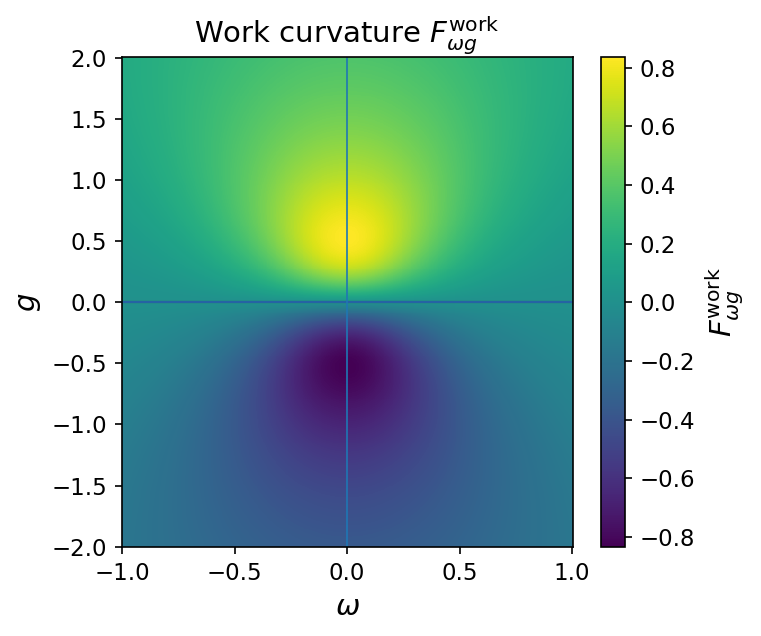

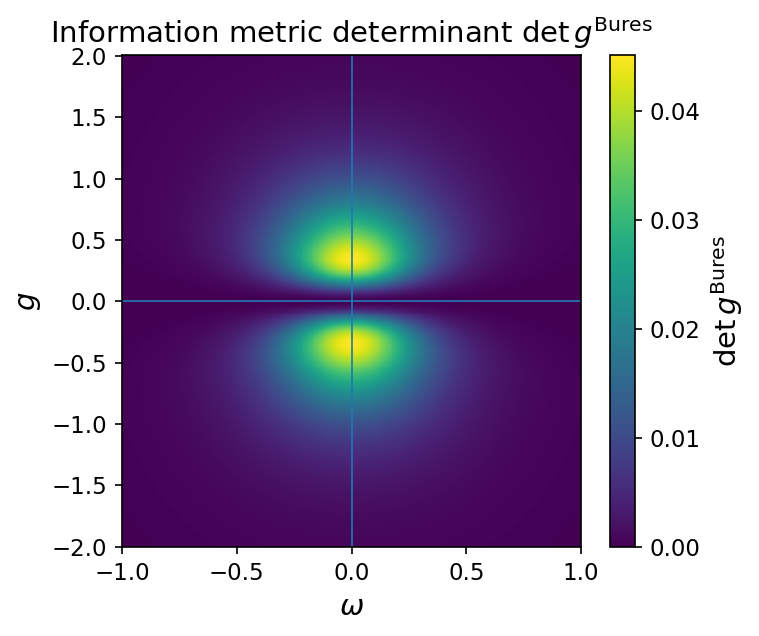

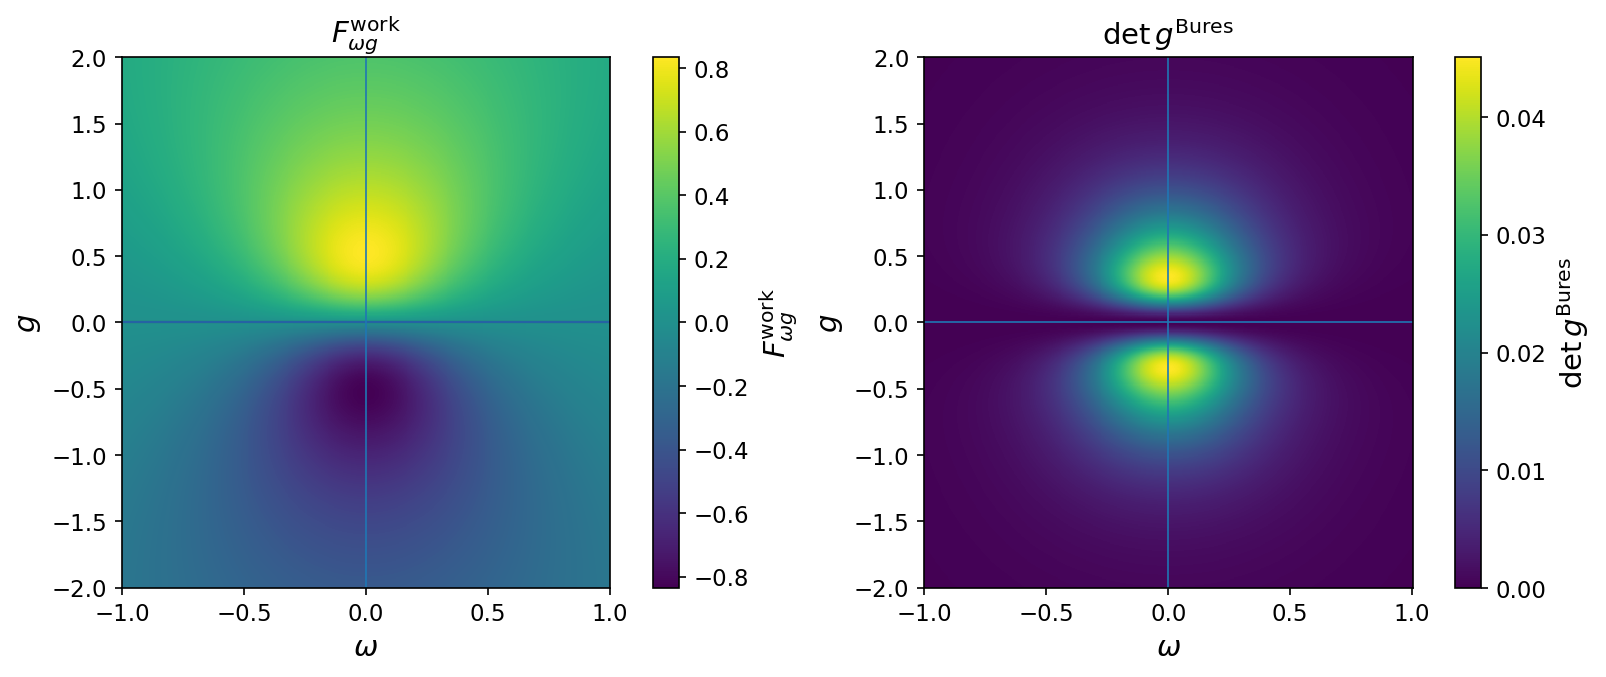

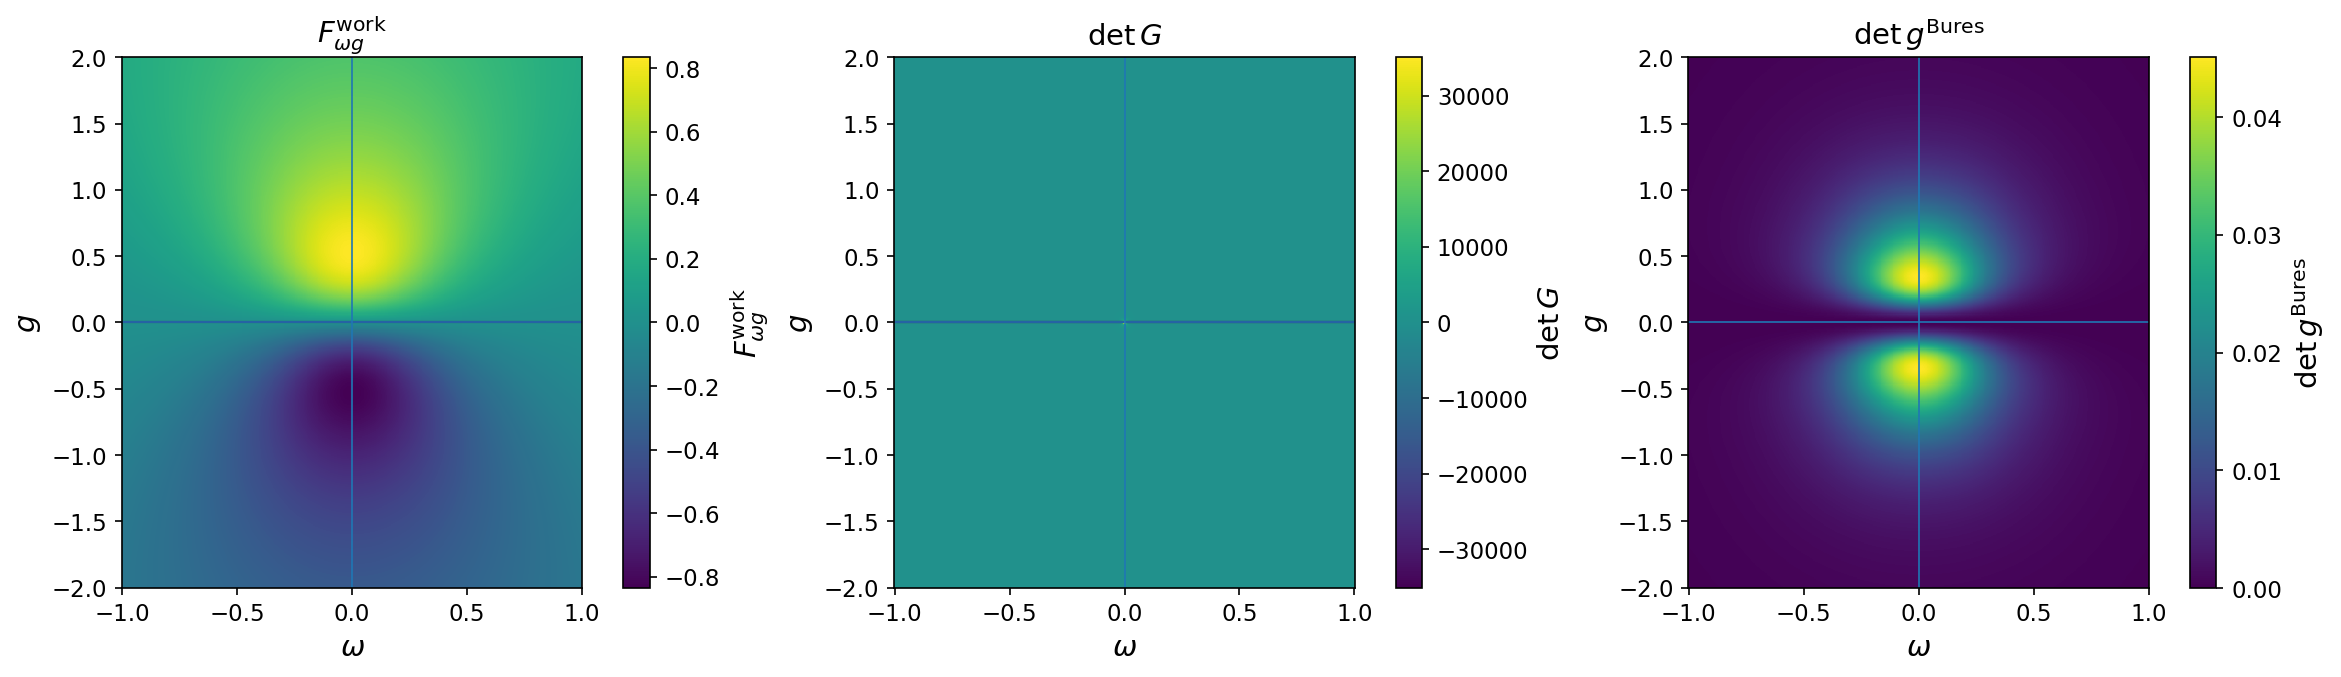

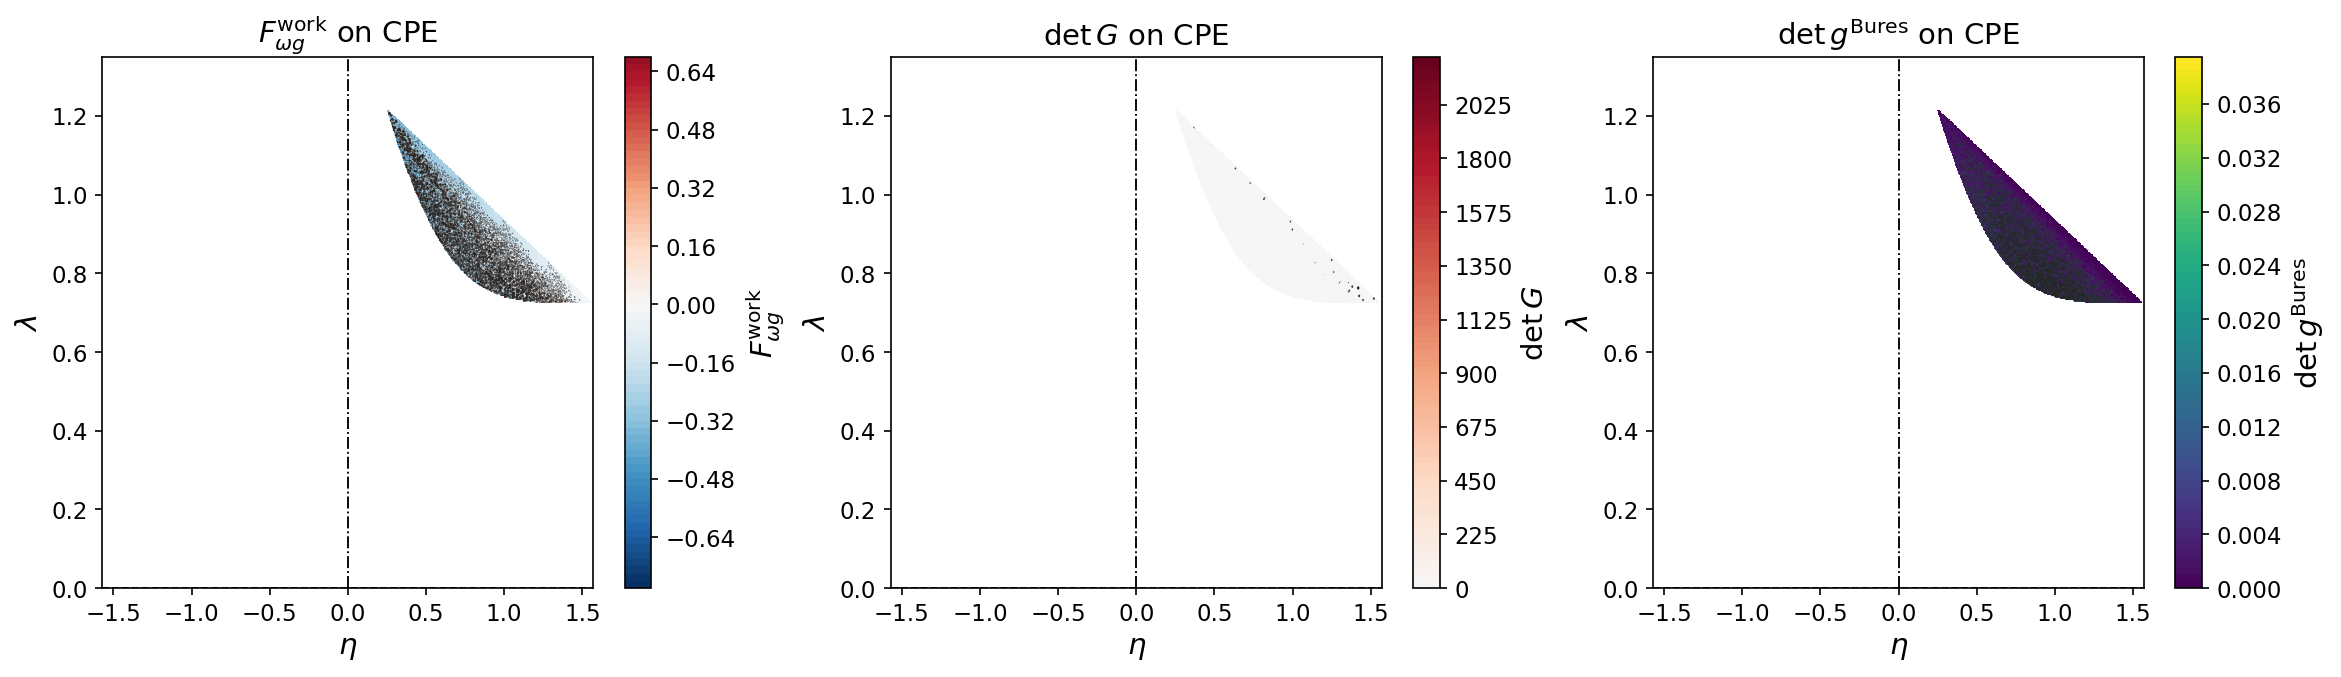

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gzip, json

outdir = Path("jcp_qubit_response_geometry")
outdir.mkdir(parents=True, exist_ok=True)

gamma = 1.0
s = 0.75
omega_min, omega_max, n_omega = -1.0, 1.0, 501
g_min, g_max, n_g = -2.0, 2.0, 501

omega_vals = np.linspace(omega_min, omega_max, n_omega)
g_vals = np.linspace(g_min, g_max, n_g)
Omega, G = np.meshgrid(omega_vals, g_vals, indexing="xy")

D = 2.0 * Omega**2 + G**2 + gamma**2 / 2.0

x = 2.0 * s * Omega * G / (gamma * D)
y = -s * G / D
z = s * (4.0 * Omega**2 + gamma**2) / (2.0 * gamma * D)
r2 = x**2 + y**2 + z**2

Dw = 4.0 * Omega
Dg = 2.0 * G

A = 2.0 * s / gamma
dx_domega = A * G * (D - Omega * Dw) / D**2
dx_dg = A * Omega * (D - G * Dg) / D**2

dy_domega = s * G * Dw / D**2
dy_dg = -s * (D - G * Dg) / D**2

B = s / (2.0 * gamma)
N = 4.0 * Omega**2 + gamma**2
Nw = 8.0 * Omega
dz_domega = B * (Nw * D - N * Dw) / D**2
dz_dg = -B * N * Dg / D**2

F_work = s * G * (G**2 + gamma**2) / D**2

den = np.maximum(1.0 - r2, 1e-14)
r_dot_omega = x * dx_domega + y * dy_domega + z * dz_domega
r_dot_g = x * dx_dg + y * dy_dg + z * dz_dg

qfi_oo = dx_domega**2 + dy_domega**2 + dz_domega**2 + (r_dot_omega**2) / den
qfi_gg = dx_dg**2 + dy_dg**2 + dz_dg**2 + (r_dot_g**2) / den
qfi_og = dx_domega * dx_dg + dy_domega * dy_dg + dz_domega * dz_dg + (r_dot_omega * r_dot_g) / den

bures_oo = qfi_oo / 4.0
bures_gg = qfi_gg / 4.0
bures_og = qfi_og / 4.0
det_bures = np.maximum(bures_oo * bures_gg - bures_og**2, 0.0)

plt.rcParams.update({
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "figure.dpi": 150, "savefig.dpi": 600, "pdf.fonttype": 42, "ps.fonttype": 42,
})

Fmax = np.max(np.abs(F_work))
Gmax = np.max(det_bures)

def save_fig(fig, basename):
    fig.savefig(outdir / f"{basename}.png", dpi=600)
    fig.savefig(outdir / f"{basename}.pdf", dpi=300)

figF, axF = plt.subplots(figsize=(5.2, 4.4))
imF = axF.pcolormesh(Omega, G, F_work, shading="auto", vmin=-Fmax, vmax=Fmax, rasterized=True)
axF.contour(Omega, G, F_work, levels=[0], linewidths=1.0)
axF.axhline(0, linewidth=0.8)
axF.axvline(0, linewidth=0.8)
axF.set_xlabel(r"$\omega$")
axF.set_ylabel(r"$g$")
axF.set_title(r"Work curvature $F_{\omega g}^{\rm work}$")
figF.colorbar(imF, ax=axF, label=r"$F_{\omega g}^{\rm work}$")
figF.tight_layout()
save_fig(figF, "Fig_Fwork_omega_g")

figG, axG = plt.subplots(figsize=(5.2, 4.4))
imG = axG.pcolormesh(Omega, G, det_bures, shading="auto", vmin=0, vmax=Gmax, rasterized=True)
axG.contour(Omega, G, F_work, levels=[0], linewidths=1.0)
axG.axhline(0, linewidth=0.8)
axG.axvline(0, linewidth=0.8)
axG.set_xlabel(r"$\omega$")
axG.set_ylabel(r"$g$")
axG.set_title(r"Information metric determinant $\det g^{\rm Bures}$")
figG.colorbar(imG, ax=axG, label=r"$\det g^{\rm Bures}$")
figG.tight_layout()
save_fig(figG, "Fig_detBures_omega_g")

figPair, axes = plt.subplots(1, 2, figsize=(10.6, 4.4), constrained_layout=True)
im0 = axes[0].pcolormesh(Omega, G, F_work, shading="auto", vmin=-Fmax, vmax=Fmax, rasterized=True)
axes[0].contour(Omega, G, F_work, levels=[0], linewidths=1.0)
axes[0].axhline(0, linewidth=0.8)
axes[0].axvline(0, linewidth=0.8)
axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$g$")
axes[0].set_title(r"$F_{\omega g}^{\rm work}$")
figPair.colorbar(im0, ax=axes[0], label=r"$F_{\omega g}^{\rm work}$")
im1 = axes[1].pcolormesh(Omega, G, det_bures, shading="auto", vmin=0, vmax=Gmax, rasterized=True)
axes[1].contour(Omega, G, F_work, levels=[0], linewidths=1.0)
axes[1].axhline(0, linewidth=0.8)
axes[1].axvline(0, linewidth=0.8)
axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$g$")
axes[1].set_title(r"$\det g^{\rm Bures}$")
figPair.colorbar(im1, ax=axes[1], label=r"$\det g^{\rm Bures}$")
save_fig(figPair, "Fig_Fwork_detBures_pair")

np.savez_compressed(
    outdir / "jcp_qubit_response_geometry_data.npz",
    omega_vals=omega_vals, g_vals=g_vals, Omega=Omega, G=G,
    x=x, y=y, z=z, r2=r2, F_work=F_work,
    bures_oo=bures_oo, bures_gg=bures_gg, bures_og=bures_og,
    det_bures=det_bures, gamma=np.array(gamma), s=np.array(s),
)

from scipy.interpolate import griddata

# ============================================================
# Response metric G from JCP2 tensor
# G_ij = d_i r . d_j r + d_i hhat . d_j hhat
# with h = (g,0,omega), hhat = h / |h|
# ============================================================

eps_h = np.sqrt(Omega**2 + G**2)
eps_safe = np.maximum(eps_h, 1e-14)

hx = G / eps_safe
hy = np.zeros_like(G)
hz = Omega / eps_safe

# analytic derivatives of hhat wrt omega and g
dhx_domega = -G * Omega / eps_safe**3
dhx_dg     =  Omega**2 / eps_safe**3

dhz_domega = G**2 / eps_safe**3
dhz_dg     = -Omega * G / eps_safe**3

# mask singular point near omega=g=0
singular = eps_h < 1e-8
dhx_domega[singular] = np.nan
dhx_dg[singular] = np.nan
dhz_domega[singular] = np.nan
dhz_dg[singular] = np.nan

G_oo = (
    dx_domega**2 + dy_domega**2 + dz_domega**2
    + dhx_domega**2 + dhz_domega**2
)

G_gg = (
    dx_dg**2 + dy_dg**2 + dz_dg**2
    + dhx_dg**2 + dhz_dg**2
)

G_og = (
    dx_domega*dx_dg + dy_domega*dy_dg + dz_domega*dz_dg
    + dhx_domega*dhx_dg + dhz_domega*dhz_dg
)

det_G = G_oo * G_gg - G_og**2


# ============================================================
# Control-grid three-panel plot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), constrained_layout=True)

Fmax = np.nanmax(np.abs(F_work))
im0 = axes[0].pcolormesh(Omega, G, F_work, shading="auto",
                         vmin=-Fmax, vmax=Fmax, rasterized=True)
axes[0].contour(Omega, G, F_work, levels=[0], linewidths=1.0)
axes[0].axhline(0, lw=0.8); axes[0].axvline(0, lw=0.8)
axes[0].set_xlabel(r"$\omega$"); axes[0].set_ylabel(r"$g$")
axes[0].set_title(r"$F_{\omega g}^{\rm work}$")
fig.colorbar(im0, ax=axes[0], label=r"$F_{\omega g}^{\rm work}$")

Gmax = np.nanmax(np.abs(det_G))
im1 = axes[1].pcolormesh(Omega, G, det_G, shading="auto",
                         vmin=-Gmax, vmax=Gmax, rasterized=True)
axes[1].contour(Omega, G, det_G, levels=[0], linewidths=1.0)
axes[1].axhline(0, lw=0.8); axes[1].axvline(0, lw=0.8)
axes[1].set_xlabel(r"$\omega$"); axes[1].set_ylabel(r"$g$")
axes[1].set_title(r"$\det G$")
fig.colorbar(im1, ax=axes[1], label=r"$\det G$")

Bmax = np.nanmax(det_bures)
im2 = axes[2].pcolormesh(Omega, G, det_bures, shading="auto",
                         vmin=0, vmax=Bmax, rasterized=True)
axes[2].contour(Omega, G, F_work, levels=[0], linewidths=1.0)
axes[2].axhline(0, lw=0.8); axes[2].axvline(0, lw=0.8)
axes[2].set_xlabel(r"$\omega$"); axes[2].set_ylabel(r"$g$")
axes[2].set_title(r"$\det g^{\rm Bures}$")
fig.colorbar(im2, ax=axes[2], label=r"$\det g^{\rm Bures}$")

save_fig(fig, "Fig_Fwork_detG_detBures_control")


# ============================================================
# CPE / Mercator projection from verified control-grid data
# ============================================================

C = np.sqrt(x**2 + y**2)
P = z
R2 = np.clip(r2, 0.0, 1.0)
E = np.sqrt(1.0 - R2)

eta_cpe = np.arctan2(P, C)
lam_cpe = np.arcsin(np.clip(E, 0.0, 1.0))

eta_grid = np.linspace(-np.pi/2, np.pi/2, 501)
lam_grid = np.linspace(0.0, 1.35, 401)
ETA, LAM = np.meshgrid(eta_grid, lam_grid)

points = np.column_stack([eta_cpe.ravel(), lam_cpe.ravel()])

def project_to_cpe(field):
    values = field.ravel()
    valid = np.isfinite(points[:,0]) & np.isfinite(points[:,1]) & np.isfinite(values)
    return griddata(points[valid], values[valid], (ETA, LAM), method="linear")

F_cpe = project_to_cpe(F_work)
G_cpe = project_to_cpe(det_G)
B_cpe = project_to_cpe(det_bures)


def plot_cpe(ax, field, title, symmetric=False, cmap=None):
    if cmap is None:
        cmap = "RdBu_r" if symmetric else "viridis"

    if symmetric:
        vmax = np.nanmax(np.abs(field))
        vmin = -vmax
    else:
        vmin = np.nanmin(field)
        vmax = np.nanmax(field)

    im = ax.contourf(ETA, LAM, field, levels=90, cmap=cmap,
                     vmin=vmin, vmax=vmax)
    ax.contour(ETA, LAM, field, levels=18, colors="0.15",
               linewidths=0.35, alpha=0.65)

    ax.axhline(0, color="k", ls="--", lw=0.9)
    ax.axvline(0, color="k", ls="-.", lw=0.9)

    ax.set_xlim(-np.pi/2, np.pi/2)
    ax.set_ylim(0, 1.35)
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\lambda$")
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), constrained_layout=True)

im0 = plot_cpe(axes[0], F_cpe, r"$F_{\omega g}^{\rm work}$ on CPE", symmetric=True)
fig.colorbar(im0, ax=axes[0], label=r"$F_{\omega g}^{\rm work}$")

im1 = plot_cpe(axes[1], G_cpe, r"$\det G$ on CPE", symmetric=True)
fig.colorbar(im1, ax=axes[1], label=r"$\det G$")

im2 = plot_cpe(axes[2], B_cpe, r"$\det g^{\rm Bures}$ on CPE", symmetric=False)
fig.colorbar(im2, ax=axes[2], label=r"$\det g^{\rm Bures}$")

save_fig(fig, "Fig_Fwork_detG_detBures_CPE_Mercator")
plt.show()